## META-LEARNING FOR QUADCOPTER CONTROL

## Definition

#### Libraries

In [1]:
import numpy as np
import scipy.linalg as la
from scipy.signal import cont2discrete
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib as mpl

# Plotting parameters
plt.style.use('default')
plt.rcParams['figure.dpi'] = 400

# Enable LaTeX rendering
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"], 
    "axes.unicode_minus": False 
})

# Consistent printing of numpy arrays
np.set_printoptions(precision=3, suppress=True)

#### System definition
$
\text{State vector:} \quad
\mathbf{x} =
\begin{bmatrix}
x & \dot{x} & y & \dot{y} & z & \dot{z} & \phi & \dot{\phi} & \theta & \dot{\theta} & \psi & \dot{\psi}
\end{bmatrix}^T
$

$
\text{Input vector:} \quad
\mathbf{u} =
\begin{bmatrix}
F & \tau_x & \tau_y & \tau_z
\end{bmatrix}^T
$

where:  
- $F$ = total thrust deviation from hover  
- $(\tau_x, \tau_y, \tau_z)$ = body torques  

*Source:* Faraz Ahmad, Pushpendra Kumar, Anamika Bhandari, Pravin P. Patil, *Simulation of the Quadcopter Dynamics with LQR based Control*


In [2]:
def quad_hover_linear_model(m, g, Ix, Iy, Iz):
    """
    Continuous-time linearized model with ABSOLUTE thrust F as input
    and an affine gravity bias c (to be handled via augmentation).
    """
    A = np.zeros((12,12))
    # kinematics
    A[0,1]  = 1.0
    A[2,3]  = 1.0
    A[4,5]  = 1.0
    A[6,7]  = 1.0
    A[8,9]  = 1.0
    A[10,11]= 1.0
    # lateral small-angle couplings: Xddot = g*theta, Yddot = -g*phi
    A[1,8]  =  g
    A[3,6]  = -g

    B = np.zeros((12,4))
    # absolute thrust -> Zddot
    B[5,0]  = 1.0/m
    # torques -> angular accels
    B[7,1]  = 1.0/Ix
    B[9,2]  = 1.0/Iy
    B[11,3] = 1.0/Iz

    # constant bias c (affine): only Zd_dot has -g
    c = np.zeros((12,1))
    c[5,0] = -g

    # Identity output by default
    C = np.eye(A.shape[0])
    D = np.zeros((12, 4))

    return A, B, C, D, c

In [3]:
def discretize(A, B, C, D, c, Ts):
    """
    Same as above but with custom CT output (y = C x + D u).  C is (p x n), D default 0.
    Returns Ad, Bd, Cd, Dd, d with y_k = Cd x_k + Dd u_k.
    """
    n, m = A.shape[0], B.shape[1]
    p = C.shape[0]

    A_aug = np.zeros((n+1, n+1))
    B_aug = np.zeros((n+1, m))
    C_aug = np.zeros((p,   n+1))   # [C  0]
    D_aug = D.copy()

    A_aug[:n, :n] = A
    A_aug[:n,  n] = c.squeeze() # replace last column with c
    B_aug[:n, :]  = B
    C_aug[:, :n]  = C

    Ad_aug, Bd_aug, Cd_aug, Dd_aug, _ = cont2discrete((A_aug, B_aug, C_aug, D_aug), Ts, method="zoh")

    Ad = Ad_aug[:n, :n]
    Bd = Bd_aug[:n, :]
    d  = Ad_aug[:n,  n]
    Cd = Cd_aug[:, :n]             # equals input C
    Dd = Dd_aug                    # equals input D
    return Ad, Bd, Cd, Dd, d

In [4]:
def _euler_zyx_to_R(phi, theta, psi):
    cphi, sphi = np.cos(phi), np.sin(phi)
    cth,  sth  = np.cos(theta), np.sin(theta)
    cpsi, spsi = np.cos(psi), np.sin(psi)

    Rx = np.array([[1, 0, 0],
                   [0, cphi, -sphi],
                   [0, sphi,  cphi]])
    Ry = np.array([[ cth, 0, sth],
                   [   0, 1,   0],
                   [-sth, 0, cth]])
    Rz = np.array([[cpsi, -spsi, 0],
                   [spsi,  cpsi, 0],
                   [   0,     0, 1]])
    return Rz @ Ry @ Rx

In [5]:
# Model parameters
m = 1.0; g = 9.81; Ix = 0.11; Iy = 0.11; Iz = 0.04; Ts = 0.01; T_sim = 8.0


# Bryson-style max acceptable magnitudes for each state
# Commands
#  F is the net upward thrust magnitude of all four rotors combined -> [0, Fmax]
Fmax = 2 * m * g; tauxmax = 0.08; tauymax = 0.08; tauzmax = 0.05
u_max = np.array([Fmax, tauxmax, tauymax, tauzmax], dtype=np.float32)
# States
Xmax, Xdmax = 5.0, 5.0
Ymax, Ydmax = 5.0, 5.0
Zmax, Zdmax = 5.0, 5.0
phimax, phidmax = np.deg2rad(30), np.deg2rad(120)       # max orientation of 30 deg and max angular rate of 120 deg/s = full rotation in 3s
thetamax, thetadmax = np.deg2rad(30), np.deg2rad(120)
psimax, psidmax = np.deg2rad(45), np.deg2rad(90)
x_scale = np.array([Xmax, Xdmax, Ymax, Ydmax, Zmax, Zdmax, phimax, phidmax, thetamax, thetadmax, psimax, psidmax], dtype=np.float32)


# Continuous-time system
A, B, C, D, c = quad_hover_linear_model(m, g, Ix, Iy, Iz)
print(f"Continuous-time system:\nA={A}\nB={B}\nC={C}\nD={D}")


# Discrete-time system
Ad, Bd, Cd, Dd, d = discretize(A, B, C, D, c, Ts)
print(f"Augmented discrete-time system (Ts={Ts}):\nAd={Ad}\nBd={Bd}\nCd={Cd}\nDd={Dd}\nd={d}")


# State/input weights (diagonals)
Q_diag = np.array([1/Xmax**2,  1/Xdmax**2, 1/Ymax**2,  1/Ydmax**2, 1/Zmax**2,  1/Zdmax**2, 1/phimax**2,  1/phidmax**2, 1/thetamax**2, 1/thetadmax**2, 1/psimax**2,  1/psidmax**2], dtype=np.float32)
Q = np.diag(Q_diag)
R_diag = np.array([1/Fmax**2, 1/tauxmax**2, 1/tauymax**2, 1/tauzmax**2], dtype=np.float32)
R = np.diag(R_diag)
print(f"Q={Q}\nR={R}")

Continuous-time system:
A=[[ 0.    1.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    9.81  0.    0.    0.  ]
 [ 0.    0.    0.    1.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   -9.81  0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    1.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    1.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    1.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]]
B=[[ 0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.   ]
 [ 0.    

#### Simulation

In [ ]:
def simulate_torch_old(Ad, Bd, K, init_pos, m, g, Ts, T_sim, Fmax, tauxmax, tauymax, tauzmax, device="cpu"):
    Ad = torch.tensor(Ad, dtype=torch.float32, device=device)
    Bd = torch.tensor(Bd, dtype=torch.float32, device=device)
    K  = torch.tensor(K,  dtype=torch.float32, device=device)

    init_pos = init_pos.to(device)  # ensure same device

    B = init_pos.shape[0]       # batch size: number of different initial positions
    n_x = Ad.shape[0]           # state dimension
    N_steps = int(T_sim / Ts)   # number of simulation steps

    X = torch.zeros(B, N_steps, n_x, device=device)
    U = torch.zeros(B, N_steps, 4, device=device)

    x = torch.zeros(B, n_x, device=device)
    x[:, 0] = init_pos[:, 0]  # X
    x[:, 2] = init_pos[:, 1]  # Y
    x[:, 4] = init_pos[:, 2]  # Z

    for k in range(N_steps):
        u = -(x @ K.T)                                      
        
        u[:, 0] = torch.clamp(u[:, 0], -Fmax, Fmax)         # clamp thrust deviation and torques
        u[:, 1] = torch.clamp(u[:, 1], -tauxmax, tauxmax)
        u[:, 2] = torch.clamp(u[:, 2], -tauymax, tauymax)
        u[:, 3] = torch.clamp(u[:, 3], -tauzmax, tauzmax)

        x = (x @ Ad.T) + (u @ Bd.T)
        X[:, k, :] = x
        U[:, k, :] = u
    return X, U

In [8]:
def simulate_torch(Ad, Bd, K, init_pos, m, g, Ts, T_sim, Fmax, tauxmax, tauymax, tauzmax, device="cpu", d=None, u_eq=None):

    # d: pass a (12,) np/torch bias vector for affine model; else None
    # u_eq: for absolute-thrust case: (4,) constant feed-forward; else None
    """
    If d is None => deviation-input model: x+ = A x + B u   with u = -K x
    If d is not None => absolute-thrust affine model: x+ = A x + B u + d with u = u_eq - K x

    init_pos: (B,3) -> sets X,Y,Z in the 12-state (others zero)
    """
    import torch
    Ad = torch.tensor(Ad, dtype=torch.float32, device=device)
    Bd = torch.tensor(Bd, dtype=torch.float32, device=device)
    K  = torch.tensor(K,  dtype=torch.float32, device=device)
    if d is not None:
        d = torch.tensor(d, dtype=torch.float32, device=device).view(1, -1)  # (1,12)
    if u_eq is not None:
        u_eq = torch.tensor(u_eq, dtype=torch.float32, device=device).view(1, -1)  # (1,4)

    B = init_pos.shape[0]
    n_x = Ad.shape[0]
    N_steps = int(T_sim / Ts)

    X = torch.zeros(B, N_steps, n_x, device=device)
    U = torch.zeros(B, N_steps, 4,   device=device)

    x = torch.zeros(B, n_x, device=device)
    x[:, 0] = init_pos[:, 0]  # X
    x[:, 2] = init_pos[:, 1]  # Y
    x[:, 4] = init_pos[:, 2]  # Z

    for k in range(N_steps):
        if d is None:
            # deviation-input model
            u = -(x @ K.T)
            # clamp deviation thrust symmetrically (e.g., ±mg) and torques
            u[:, 0] = torch.clamp(u[:, 0], -Fmax, Fmax)
        else:
            # absolute-thrust affine model
            assert u_eq is not None, "Provide u_eq for affine/absolute-thrust simulation."
            u = u_eq - (x @ K.T)
            # clamp absolute thrust to [0, Fmax] physically (or [Fmin, Fmax] if you have a minimum)
            u[:, 0] = torch.clamp(u[:, 0], 0.0, Fmax)

        # clamp torques
        u[:, 1] = torch.clamp(u[:, 1], -tauxmax, tauxmax)
        u[:, 2] = torch.clamp(u[:, 2], -tauymax, tauymax)
        u[:, 3] = torch.clamp(u[:, 3], -tauzmax, tauzmax)

        # state update
        if d is None:
            x = (x @ Ad.T) + (u @ Bd.T)
        else:
            x = (x @ Ad.T) + (u @ Bd.T) + d

        X[:, k, :] = x
        U[:, k, :] = u

    return X, U

#### Ploting/animation

In [9]:
def animate_trajectories(X, Ts, T_sim, filename, triad_scale=0.6, triad_lw=1.0, trail_lw=2.0, stride=1, progress=True):
    # Retrieve trajectories
    ix, iy, iz = 0, 2, 4
    iphi, itheta, ipsi = 6, 8, 10
    if hasattr(X, "detach"):  # torch tensor
        X = X.detach().cpu().numpy()
    B, T, n = X.shape
    xs, ys, zs = X[:, :, ix], X[:, :, iy], X[:, :, iz]

    # Derive/validate counts
    N_expected = int(round(T_sim / Ts))
    if T != N_expected:
        print(f"[warn] T={T} differs from T_sim/Ts={N_expected}. Using T={T} from data.")

    # Frame list & fps to keep duration = T * Ts (≈ T_sim)
    frames = list(range(0, T, max(1, int(stride))))
    fps = max(1, int(round((1.0 / Ts) / max(1, int(stride)))))  # (1/Ts)/stride

    # Figure
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    fig.subplots_adjust(right=0.65)

    axis_lim = 5.0
    ax.set_xlim([-axis_lim, axis_lim])
    ax.set_ylim([-axis_lim, axis_lim])
    ax.set_zlim([-axis_lim, axis_lim])
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
    ax.set_title(fr"Quadcopter trajectories ($T_{{\mathrm{{sim}}}}\approx {len(frames)/fps:.2f}\,\mathrm{{s}}$)")

    colors = plt.cm.viridis(np.linspace(0, 1, B))

    trails = []
    markers = []
    for b in range(B):
        # initial position for legend label
        x0 = xs[b, 0]
        y0 = ys[b, 0]
        z0 = zs[b, 0]
        label = f"Batch {b}: ({x0:.1f}, {y0:.1f}, {z0:.1f})"

        line, = ax.plot([], [], [], lw=trail_lw, color=colors[b], label=label)
        point, = ax.plot([], [], [], "o", color=colors[b])
        trails.append(line)
        markers.append(point)

    # Add legend once, after creating the lines
    ax.legend(loc="upper left", bbox_to_anchor=(1.15, 1.1), fontsize=8)

    colors = plt.cm.viridis(np.linspace(0, 1, B))
    trails  = [ax.plot([], [], [], lw=trail_lw, color=colors[b])[0] for b in range(B)]
    markers = [ax.plot([], [], [], "o", color=colors[b])[0] for b in range(B)]

    # Triads: R/G/B for body x/y/z
    triads = []
    for _ in range(B):
        tx, = ax.plot([], [], [], lw=triad_lw, color="r")
        ty, = ax.plot([], [], [], lw=triad_lw, color="g")
        tz, = ax.plot([], [], [], lw=triad_lw, color="b")
        triads.append((tx, ty, tz))

    def _euler_zyx_to_R(phi, theta, psi):
        cph, sph = np.cos(phi), np.sin(phi)
        cth, sth = np.cos(theta), np.sin(theta)
        cps, sps = np.cos(psi), np.sin(psi)
        Rx = np.array([[1,0,0],[0,cph,-sph],[0,sph,cph]])
        Ry = np.array([[cth,0,sth],[0,1,0],[-sth,0,cth]])
        Rz = np.array([[cps,-sps,0],[sps,cps,0],[0,0,1]])
        return Rz @ Ry @ Rx

    def init():
        return trails + markers + [l for tri in triads for l in tri]

    def update(i):
        if progress and (i % max(1, len(frames)//50) == 0):
            # progress over *rendered* frames
            print(f"Frame {frames.index(i)+1}/{len(frames)}")

        for b in range(B):
            # trail & marker at frame i
            trails[b].set_data(xs[b, :i], ys[b, :i])
            trails[b].set_3d_properties(zs[b, :i])
            markers[b].set_data([xs[b, i]], [ys[b, i]])
            markers[b].set_3d_properties([zs[b, i]])

            # attitude triad at pose i
            phi, theta, psi = X[b, i, iphi], X[b, i, itheta], X[b, i, ipsi]
            R = _euler_zyx_to_R(phi, theta, psi)
            p = np.array([xs[b, i], ys[b, i], zs[b, i]])
            ex, ey, ez = R[:,0], R[:,1], R[:,2]
            tx, ty, tz = triads[b]
            px, py, pz = p + triad_scale*ex, p + triad_scale*ey, p + triad_scale*ez
            tx.set_data([p[0], px[0]], [p[1], px[1]]); tx.set_3d_properties([p[2], px[2]])
            ty.set_data([p[0], py[0]], [p[1], py[1]]); ty.set_3d_properties([p[2], py[2]])
            tz.set_data([p[0], pz[0]], [p[1], pz[1]]); tz.set_3d_properties([p[2], pz[2]])
        return trails + markers + [l for tri in triads for l in tri]

    ani = FuncAnimation(fig, update, frames=frames, init_func=init, blit=False)

    fps = int(round(1.0 / Ts))  # 100 for Ts=0.01
    writer = FFMpegWriter(fps=fps, codec="libx264", bitrate=-1)
    ani.save(filename, writer=writer)
    plt.close(fig)

In [10]:
def plot_angles(X, Ts, filename):
    if hasattr(X, "detach"):  # torch tensor
        X = X.detach().cpu().numpy()

    B, T, n = X.shape
    t = np.arange(T) * Ts

    fig, axs = plt.subplots(B, 1, sharex=True, figsize=(8, 2.6 * B))
    axs = np.atleast_1d(axs)

    for b in range(B):
        roll  = X[b, :, 6] 
        pitch = X[b, :, 8] 
        yaw   = X[b, :, 10]

        x0 = X[b, 0, 0] 
        y0 = X[b, 0, 2] 
        z0 = X[b, 0, 4]

        axs[b].plot(t, np.rad2deg(roll),  label="Roll $\phi$")
        axs[b].plot(t, np.rad2deg(pitch), label="Pitch $\\theta$")
        axs[b].plot(t, np.rad2deg(yaw),   label="Yaw  $\psi$")
        axs[b].grid(True)
        axs[b].set_ylabel("Angle [°]")
        axs[b].set_title(f"Batch {b}: ({x0:.1f}, {y0:.1f}, {z0:.1f})")
        axs[b].legend(loc="best")

    axs[-1].set_xlabel("Time [s]")
    fig.tight_layout()
    plt.savefig(filename, dpi=400)
    plt.close(fig)

In [11]:
def plot_xyz(X, Ts, filename):
    if hasattr(X, "detach"):  # torch tensor
        X = X.detach().cpu().numpy()

    B, T, n = X.shape
    t = np.arange(T) * Ts

    fig, axs = plt.subplots(B, 1, sharex=True, figsize=(8, 2.6 * B))
    axs = np.atleast_1d(axs)

    for b in range(B):
        x = X[b, :, 0] 
        y = X[b, :, 2]
        z = X[b, :, 4] 

        x0 = X[b, 0, 0] 
        y0 = X[b, 0, 2] 
        z0 = X[b, 0, 4]

        axs[b].plot(t, x, label="x")
        axs[b].plot(t, y, label="y")
        axs[b].plot(t, z, label="z")
        axs[b].grid(True)
        axs[b].set_ylabel("Position [m]")
        axs[b].set_title(f"Batch {b}: ({x0:.1f}, {y0:.1f}, {z0:.1f})")
        axs[b].legend(loc="best")

    axs[-1].set_xlabel("Time [s]")
    fig.tight_layout()
    plt.savefig(filename, dpi=400)
    plt.close(fig)

In [12]:
def plot_controls_grid(U, Ts, m, g, Fmax, tauxmax, tauymax, tauzmax, X_for_titles, filename):
    if hasattr(U, "detach"):  # torch tensor
        U = U.detach().cpu().numpy()
    B, T, m_in = U.shape
    assert m_in == 4, "U must be shape (B, T, 4)"

    t = np.arange(T) * Ts

    col_meta = [
        ("Thrust $F$ [N]",          Fmax),
        (r"$\tau_x$ [N$\cdot$m]",   tauxmax),
        (r"$\tau_y$ [N$\cdot$m]",   tauymax),
        (r"$\tau_z$ [N$\cdot$m]",   tauzmax),
    ]

    # optional titles per row
    row_titles = [f"Batch {b}" for b in range(B)]
    if X_for_titles is not None:
        Xn = X_for_titles.detach().cpu().numpy() if hasattr(X_for_titles, "detach") else X_for_titles
        for b in range(B):
            x0, y0, z0 = Xn[b, 0, 0], Xn[b, 0, 2], Xn[b, 0, 4]
            row_titles[b] = f"Batch {b} — $(x_0,y_0,z_0)=({x0:.1f},{y0:.1f},{z0:.1f})$"

    # figure
    fig, axs = plt.subplots(B, 4, sharex='col', figsize=(4*4, 2.6*B), squeeze=False)

    for b in range(B):
        for j, (ylabel, umax) in enumerate(col_meta):
            ax = axs[b, j]
            ax.plot(t, U[b, :, j], label="command")

            if j == 0:  # thrust: [0, Fmax]
                ax.axhline(0.0, ls="--", c="k", lw=1, alpha=0.7,
                        label="min" if (b==0 and j==0) else None)
                ax.axhline(umax, ls="--", c="k", lw=1, alpha=0.7,
                        label="max" if (b==0 and j==0) else None)
            else:       # torques: [-umax, +umax]
                ax.axhline( umax, ls="--", c="k", lw=1, alpha=0.7,
                        label="+limit" if (b==0 and j==1) else None)
                ax.axhline(-umax, ls="--", c="k", lw=1, alpha=0.7,
                        label="-limit" if (b==0 and j==1) else None)

            ax.grid(True)
            if b == 0:
                ax.set_title(ylabel)
            if b == B-1:
                ax.set_xlabel("Time [s]")
            if j == 0:
                ax.set_ylabel(row_titles[b])

    # one legend (top-left only) to avoid clutter
    axs[0,0].legend(loc="best")

    fig.tight_layout()
    plt.savefig(filename, dpi=400)
    plt.close(fig)

#### LQR controller

In [13]:
def design_lqr(Ad, Bd, Q, R):
    # Discrete-time LQR
    P = la.solve_discrete_are(Ad, Bd, Q, R)
    K_LQR = np.linalg.inv(Bd.T @ P @ Bd + R) @ (Bd.T @ P @ Ad)
    return K_LQR

#### NN controller

In [6]:
# Policy: small MLP with tanh + limits (smooth saturation)
class PolicyMLP(nn.Module):
    
    def __init__(self, x_scale, u_max, hidden=64):
        super().__init__()
        self.register_buffer("x_scale", torch.tensor(x_scale, dtype=torch.float32))  # (12,)
        self.register_buffer("u_max",   torch.tensor(u_max,   dtype=torch.float32))  # (4,)
        self.net = nn.Sequential(
            nn.Linear(12, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 4),
        )

    # def forward(self, x):                        # x: (..., 12)
    #     x_n = x / self.x_scale                   # normalize inputs
    #     u   = self.net(x_n)
    #     return torch.tanh(u) * self.u_max        # smooth clamp to limits
    

    def forward(self, x):
        x_n = x / self.x_scale
        u   = self.net(x_n)

        # Torques: symmetric [-1,1] → [-umax, umax]
        torques = torch.tanh(u[..., 1:]) * self.u_max[1:]

        # Thrust: force ≥ 0 → [0, umax] using sigmoid
        thrust = torch.sigmoid(u[..., [0]]) * self.u_max[0] # replaced tanh with sigmoid to enforce non-negative thrust

        return torch.cat([thrust, torques], dim=-1)

In [7]:
# Rollout: differentiable plant x_{k+1} = Ad x_k + Bd u_k
@torch.no_grad()
def make_x0_batch(xyz_list):
    X0 = torch.zeros(len(xyz_list), 12, dtype=torch.float32)
    for b, p in enumerate(xyz_list):
        x, y, z = float(p[0]), float(p[1]), float(p[2])
        X0[b,0] = x; X0[b,2] = y; X0[b,4] = z
    return X0

In [8]:
# Even with fewer base points, add small random perturbations each step so the policy doesn’t overfit exact coordinates:

def sample_ic_batch(base_points, B=None, jitter=0.5, device="cpu"):
    base = torch.tensor(base_points, dtype=torch.float32)
    if B is None:  # use all base points once
        pts = base.clone()
    else:          # sample B of them
        idx = torch.randint(0, base.shape[0], (B,))
        pts = base[idx]
    pts += (2*torch.rand_like(pts) - 1) * jitter   # ±jitter meters
    return pts.clamp(-5.0, 5.0).to(device)

In [18]:
def rollout_policy(Ad, Bd, d, policy, x0, T_steps):
    """
    Ad, Bd: torch.FloatTensor (12x12), (12x4) on same device as policy
    x0: (B,12) initial states
    returns X (B,T,12), U (B,T,4)
    """
    B = x0.shape[0]; n = Ad.shape[0]; m = Bd.shape[1]
    X = torch.zeros(B, T_steps, n, device=Ad.device)
    U = torch.zeros(B, T_steps, m, device=Ad.device)
    x = x0

    d = d.view(1, -1)  # broadcast over batch
    for k in range(T_steps):
        u = policy(x)             # (B,4)

        print(d)

        x = (x @ Ad.T) + (u @ Bd.T) + d

        print()

        X[:,k,:] = x
        U[:,k,:] = u
    return X, U

In [10]:
# Cost: sum_k x'Qx + u'Ru (batched over trajectories)
def traj_cost(X, U, Q_diag, R_diag, terminal_pos_weight=0.0):
    """
    X: (B,T,12), U:(B,T,4)
    Q_diag: (12,), R_diag: (4,)   (torch or numpy)
    """
    Q = torch.as_tensor(Q_diag, dtype=X.dtype, device=X.device)
    R = torch.as_tensor(R_diag, dtype=U.dtype, device=U.device)
    stage_x = (X**2) * Q                      # (B,T,12)
    stage_u = (U**2) * R                      # (B,T,4)
    L = stage_x.sum(dim=2).mean(dim=0).sum()  # sum over state dims, mean over batch, sum over time
    L += stage_u.sum(dim=2).mean(dim=0).sum()
    if terminal_pos_weight > 0.0:
        pT = X[:, -1, [0,2,4]]                # terminal XYZ
        L += terminal_pos_weight * (pT**2).mean()
    return L

In [11]:
# Training loop
def train_nn_policy(Ad_np, Bd_np, d_np,
                    init_batches,     # list of lists of (x,y,z), one batch per iter
                    Ts, T_sim,
                    x_scale, u_max,   # normalization and control limits
                    Q_diag, R_diag,   # cost weights
                    lr=1e-3, epochs=2000,
                    terminal_pos_weight=0.0,
                    device="cpu", verbose_every=100):
    """
    init_batches: e.g. [[(0,2,3), (2,0,3), (2,2,3)], [(0,2,3)], ...]
                  Each element is a batch of start states for one optimizer step.
    """
    Ad = torch.tensor(Ad_np, dtype=torch.float32, device=device)
    Bd = torch.tensor(Bd_np, dtype=torch.float32, device=device)
    d  = torch.tensor(d_np,     dtype=torch.float32, device=device)
    T_steps = int(T_sim / Ts)

    policy = PolicyMLP(x_scale=x_scale, u_max=u_max).to(device)
    opt = torch.optim.Adam(policy.parameters(), lr=lr)

    for ep in range(epochs):
        # Iterate over provided batches of initial conditions
        for xyz_list in init_batches:
            x0 = make_x0_batch(xyz_list).to(device)

            # rollout (differentiable through policy & plant)
            X, U = rollout_policy(Ad, Bd, d, policy, x0, T_steps)

            # loss = sum_k x'Qx + u'Ru (+ optional terminal penalty)
            loss = traj_cost(X, U, Q_diag, R_diag, terminal_pos_weight)

            # SGD step
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
            opt.step()

        if verbose_every and ((ep+1) % verbose_every == 0):
            with torch.no_grad():
                p_end = X[:, -1, [0,2,4]].norm(dim=1).mean().item()
            print(f"[ep {ep+1}/{epochs}] loss={loss.item():.4e} |x_T|_avg={p_end:.3f}")

    return policy

## Testing controllers

#### Initial conditions

In [14]:
# Batch of initial positions: (x, y, z) coordiniates for each batch
x0_s = [
        # center
        [0,0,0]
]

#### Running LQR controller

In [ ]:
# Design LQR controller (x_(k+1) = Ad x_k + Bd u_k; u_(k) = - K x_(k))
u_eq = - np.linalg.pinv(Bd) @ d     # constant that cancels bias at origin
# u_eq = u_eq*0
K_LQR = design_lqr(Ad, Bd, Q, R)
# K_LQR = K_LQR*0
print(f"LQR gain K={K_LQR}")
 
init_pos = torch.tensor(x0_s, dtype=torch.float32)

# Simulate
X_LQR, U_LQR = simulate_torch(Ad, Bd, K_LQR, init_pos, m, g, Ts, T_sim, Fmax=2*m*g, tauxmax=0.15, tauymax=0.15, tauzmax=0.10, d=d, u_eq=u_eq)
print("Simulation done.")

# Plot results
plot_angles(X_LQR, Ts, "lqr_angles.png")
plot_xyz(X_LQR, Ts, "lqr_xyz.png")
plot_controls_grid(U_LQR, Ts, m, g, Fmax, tauxmax, tauymax, tauzmax, X_LQR, "lqr_controls.png")

# Create animation
print("Generating animation...")
animate_trajectories(X_LQR, Ts, T_sim, "lqr_3d_xyz.mp4")
print("All done.")

LQR gain K=[[ 0.     0.     0.     0.     3.831  4.726 -0.    -0.     0.     0.
   0.     0.   ]
 [-0.    -0.    -0.016 -0.044 -0.    -0.     0.539  0.346 -0.    -0.
   0.     0.   ]
 [ 0.016  0.044 -0.    -0.     0.     0.     0.    -0.     0.539  0.346
   0.     0.   ]
 [ 0.     0.    -0.    -0.     0.     0.     0.     0.     0.     0.
   0.063  0.078]]
Simulation done.
Generating animation...
Frame 1/800
Frame 17/800
Frame 33/800
Frame 49/800
Frame 65/800
Frame 81/800
Frame 97/800
Frame 113/800
Frame 129/800
Frame 145/800
Frame 161/800
Frame 177/800
Frame 193/800
Frame 209/800
Frame 225/800
Frame 241/800
Frame 257/800
Frame 273/800
Frame 289/800
Frame 305/800
Frame 321/800
Frame 337/800
Frame 353/800
Frame 369/800
Frame 385/800
Frame 401/800
Frame 417/800
Frame 433/800
Frame 449/800
Frame 465/800
Frame 481/800
Frame 497/800
Frame 513/800
Frame 529/800
Frame 545/800
Frame 561/800
Frame 577/800
Frame 593/800
Frame 609/800
Frame 625/800
Frame 641/800
Frame 657/800
Frame 673/800
Frame 

#### Running NN controller

In [19]:
device = "cpu"

# Build a list of "minibatches" of initial conditions (always the same one=strong overfit to that start)
init_batches = [[tuple(ic) for ic in x0_s]]  # -> [ [(0,2,2),(3,0,-4),(2,4,5),(-4,2,-5)] ] 1 step per epoch (single batch with all points)
# init_batches = [[tuple(ic)] for ic in x0_s]  # -> [ [(0,2,2)], [(3,0,-4)], [(2,4,5)], [(-4,2,-5)] ] 4 steps per epoch (4 batches with 1 point each)

# Train NN policy
policy = train_nn_policy(
    Ad_np=Ad, Bd_np=Bd, d_np=d,
    init_batches=init_batches,
    Ts=Ts, T_sim=T_sim,
    x_scale=x_scale, u_max=u_max,
    Q_diag=Q_diag, R_diag=R_diag,
    lr=1e-3, epochs=1500,               # learning rate = θ←θ−lr⋅∇θ​L (step in gradient descent) | epoch = a full loop over your dataset of batches
    terminal_pos_weight=10.0,           # nudges position error at T to be small (make sure it actually ends up at the target)
    device=device, verbose_every=100
)
Ad_t = torch.tensor(Ad, dtype=torch.float32, device=device)
Bd_t = torch.tensor(Bd, dtype=torch.float32, device=device)
d_t  = torch.tensor(d,     dtype=torch.float32, device=device)
T_steps = int(T_sim / Ts)

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -0.0005, -0.0981,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000]])

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -0.0005, -0.0981,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000]])

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -0.0005, -0.0981,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000]])

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -0.0005, -0.0981,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000]])

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -0.0005, -0.0981,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000]])

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -0.0005, -0.0981,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000]])

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -0.0005, -0.0981,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000]])

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -0.0005, -0.0981,  0.0000,  0.0000,
          0.0000

KeyboardInterrupt: 

In [ ]:
d_g = -cfg.G
print(d_g*B_tilde_d[:, [4]]) 


In [25]:
# Evaluate on training data (same initial condition as training) and other points

# Fix the seed so points are the same across runs
rng = np.random.default_rng(seed=42)

# 20 random initial conditions in (-5,5)³
testing_points = (rng.random((20, 3)) * 10 - 5).tolist()
print("Fixed random test points:", testing_points)
  
X0_all = make_x0_batch(testing_points).to(device)

with torch.no_grad():
    X_NN, U_NN = rollout_policy(Ad_t, Bd_t, d_t, policy, X0_all, T_steps)  # (B,T,12), (B,T,4)

plot_xyz(X_NN, Ts, filename="nn_xyz.png")
plot_angles(X_NN, Ts, filename="nn_angles.png")
plot_controls_grid(U_NN, Ts, m, g, Fmax, tauxmax, tauymax, tauzmax, X_NN, filename="nn_controls.png")
animate_trajectories(X_NN, Ts, T_sim, "nn_3d_xyz.mp4")

Fixed random test points: [[2.7395604855596334, -0.6112156024794766, 3.585979199113824], [1.9736802905936388, -4.058226521123505, 4.756223516367559], [2.6113970199035297, 2.8606430527695377, -3.7188636732445413], [-0.49614062104432843, -1.2920197576741876, 4.267649888486018], [1.4386512008066452, 3.227616132708299, -0.5658580117266885], [-2.727612782152231, 0.5458478701583482, -4.3618274389582465], [3.27631171992582, 1.3166439912206487, 2.5808774008537387], [-1.4547403187013161, 4.706980243949033, 3.9312112132219763], [2.783834970737619, -3.0536129214803243, -0.3327899627296578], [-4.561962342127712, -3.4571050793245215, 1.8304895324245463], [2.447621559078171, 4.675097324342101, -1.7417464186184803], [-1.2954029396513111, -0.30444188724192056, -3.1052864091571433], [-3.7007849466452836, -0.24295073774066278, -2.7309065094911587], [1.698139946825103, -0.6284808112766926, 3.3267819605783746], [2.0026510200224914, -1.8763335861795891, 3.3225980139520104], [3.047643574968019, -1.125216209

#### Comparing with metrics

In [26]:
# Compute LQR trajectory for testing points of NN
init_pos_testing = torch.tensor(testing_points, dtype=torch.float32)
X_LQR_TESTING, U_LQR_TESTING = simulate_torch(Ad, Bd, K_LQR, init_pos_testing, m, g, Ts, T_sim, Fmax=2*m*g, tauxmax=0.15, tauymax=0.15, tauzmax=0.10, d=d, u_eq=u_eq)

In [27]:
print(X_LQR.shape, U_LQR.shape, X_NN.shape, U_NN.shape)  # (B,T,12), (B,T,4)

POS_IDX = [0,2,4]

# Terminal position error |x(T)|
def terminal_pos_error(X):  # (B,T,12)
    pT = X[:, -1, POS_IDX]
    return torch.linalg.norm(pT, dim=1)  # (B,)

# Cumulative cost ∑(x'Qx + u'Ru) + terminal_pos_weight * |x(T)|^2
def cum_cost(X, U, Q_diag, R_diag, terminal_pos_weight=0.0):
    Q = torch.as_tensor(Q_diag, dtype=X.dtype, device=X.device).view(1,1,-1)
    R = torch.as_tensor(R_diag, dtype=U.dtype, device=U.device).view(1,1,-1)
    Lx = (X**2 * Q).sum(dim=2)  # (B,T)
    Lu = (U**2 * R).sum(dim=2)  # (B,T)
    J  = (Lx + Lu).sum(dim=1)   # sum over time -> (B,)
    if terminal_pos_weight > 0:
        pT = X[:, -1, POS_IDX]
        J = J + terminal_pos_weight * (pT**2).sum(dim=1)
    return J  # (B,)

# Path deviation with time-warping (robust to delays)
def dtw_path_distance(P, Q):  # P,Q: (T,3) positions; simple L2 DTW
    T = P.shape[0]
    D = torch.cdist(P.unsqueeze(0), Q.unsqueeze(0), p=2).squeeze(0)  # (T,T)
    C = torch.full((T+1, T+1), float('inf'), device=P.device)
    C[0,0] = 0.0
    for i in range(1, T+1):
        # vectorize inner loop moderately
        j = torch.arange(1, T+1, device=P.device)
        prev = torch.stack([C[i-1, j], C[i, j-1], C[i-1, j-1]], dim=0).min(dim=0).values
        C[i, 1:] = prev + D[i-1, :]
    return C[T, T]

def batch_dtw_distance(X_ref, X_test):  # both (B,T,12)
    B, T, _ = X_ref.shape
    d = []
    for b in range(B):
        Pref = X_ref[b, :, POS_IDX]
        Ptest= X_test[b, :, POS_IDX]
        d.append(dtw_path_distance(Pref, Ptest))
    return torch.stack(d)  # (B,)

def path_length(X):
    P = X[..., POS_IDX]                 # (B,T,3)
    dP = P[:, 1:, :] - P[:, :-1, :]     # (B,T-1,3)
    seg = torch.linalg.norm(dP, dim=-1) # (B,T-1)
    return seg.sum(dim=1)               # (B,)

def path_length_ratio(X_ref, X_test):
    L_ref  = path_length(X_ref)
    L_test = path_length(X_test)
    ratio  = L_test / (L_ref + 1e-12)
    excess_pct = (ratio - 1.0) * 100.0
    return ratio, excess_pct

torch.Size([27, 800, 12]) torch.Size([27, 800, 4]) torch.Size([20, 800, 12]) torch.Size([20, 800, 4])


[1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001
 1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001]


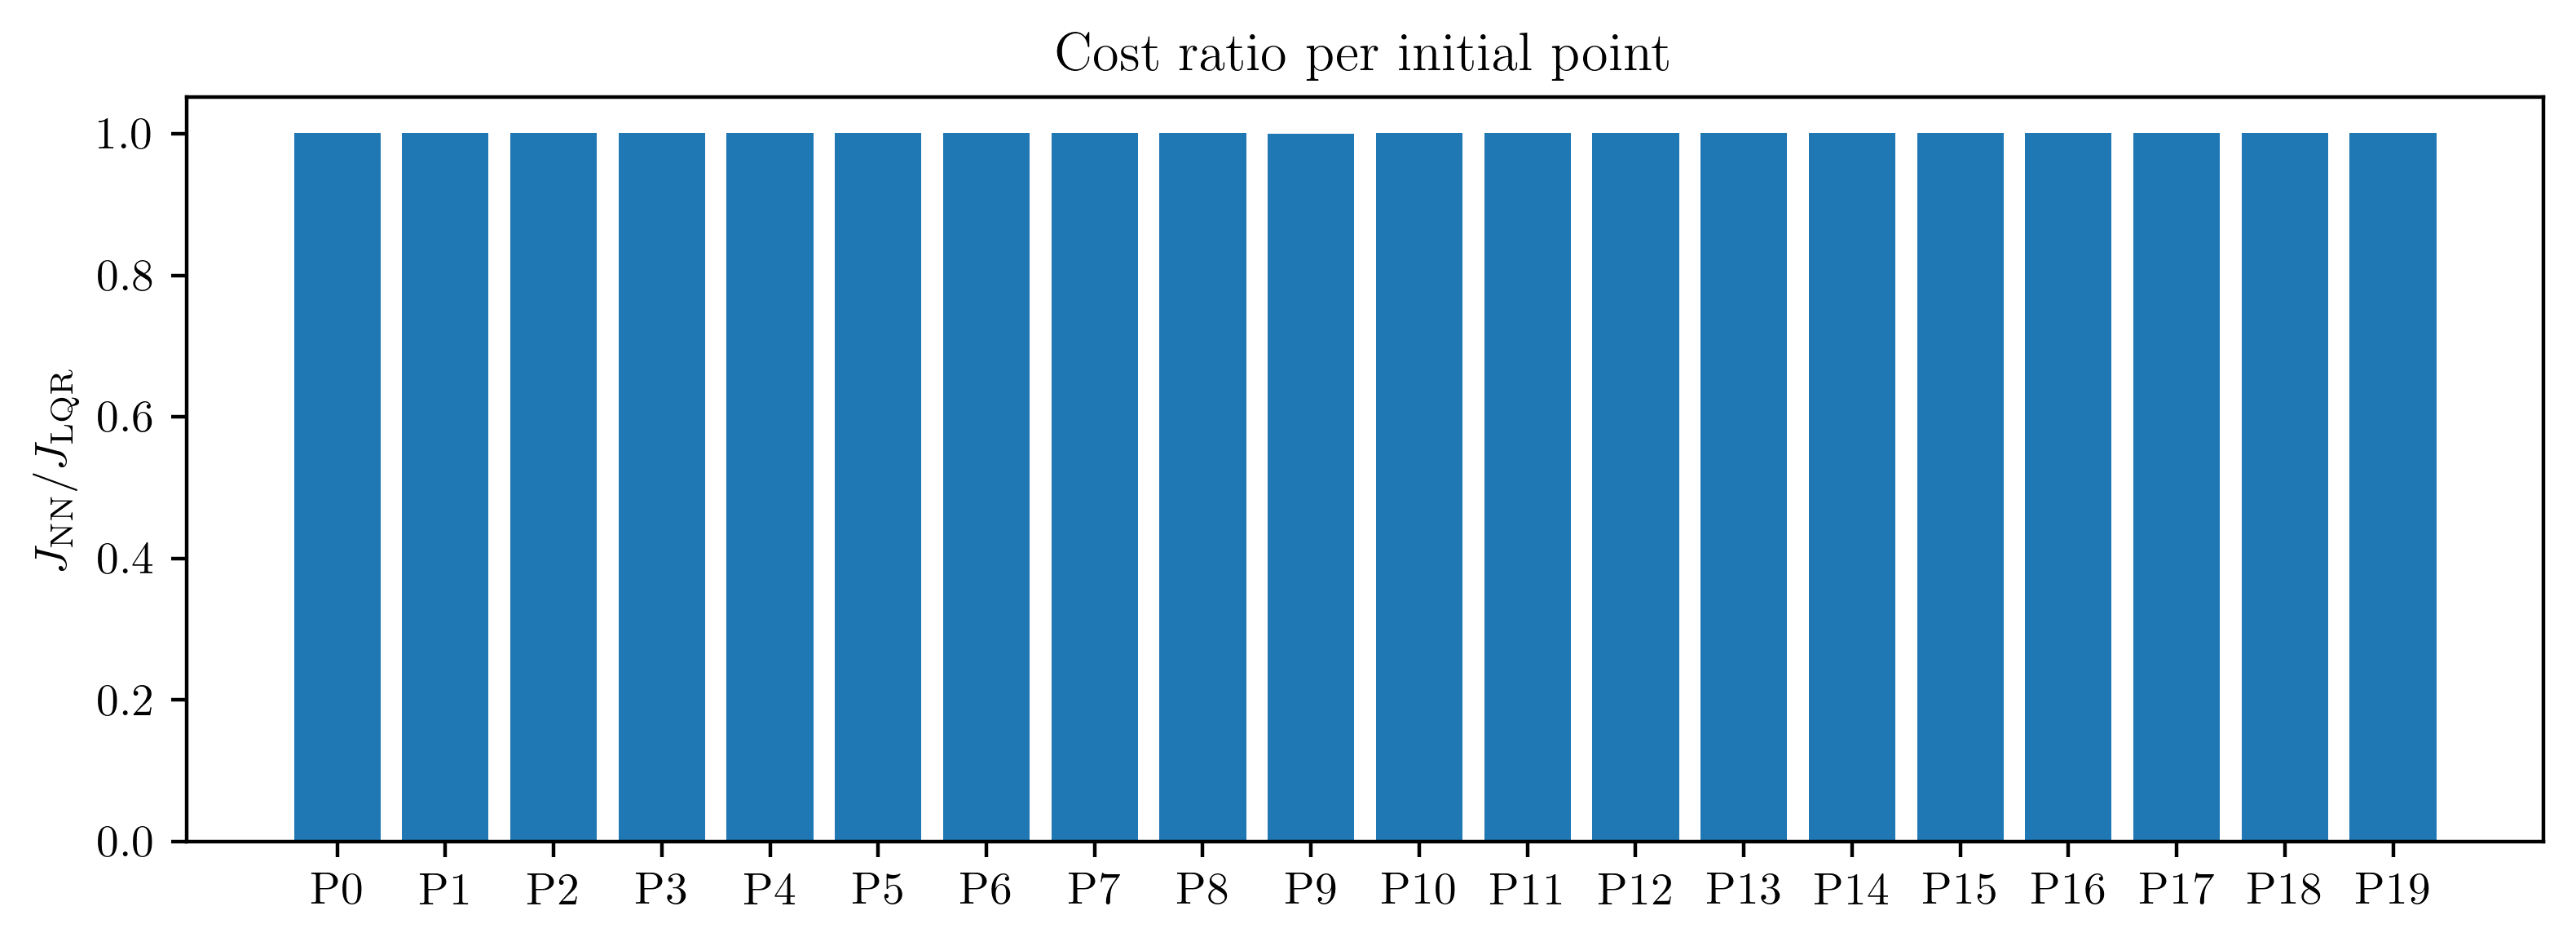

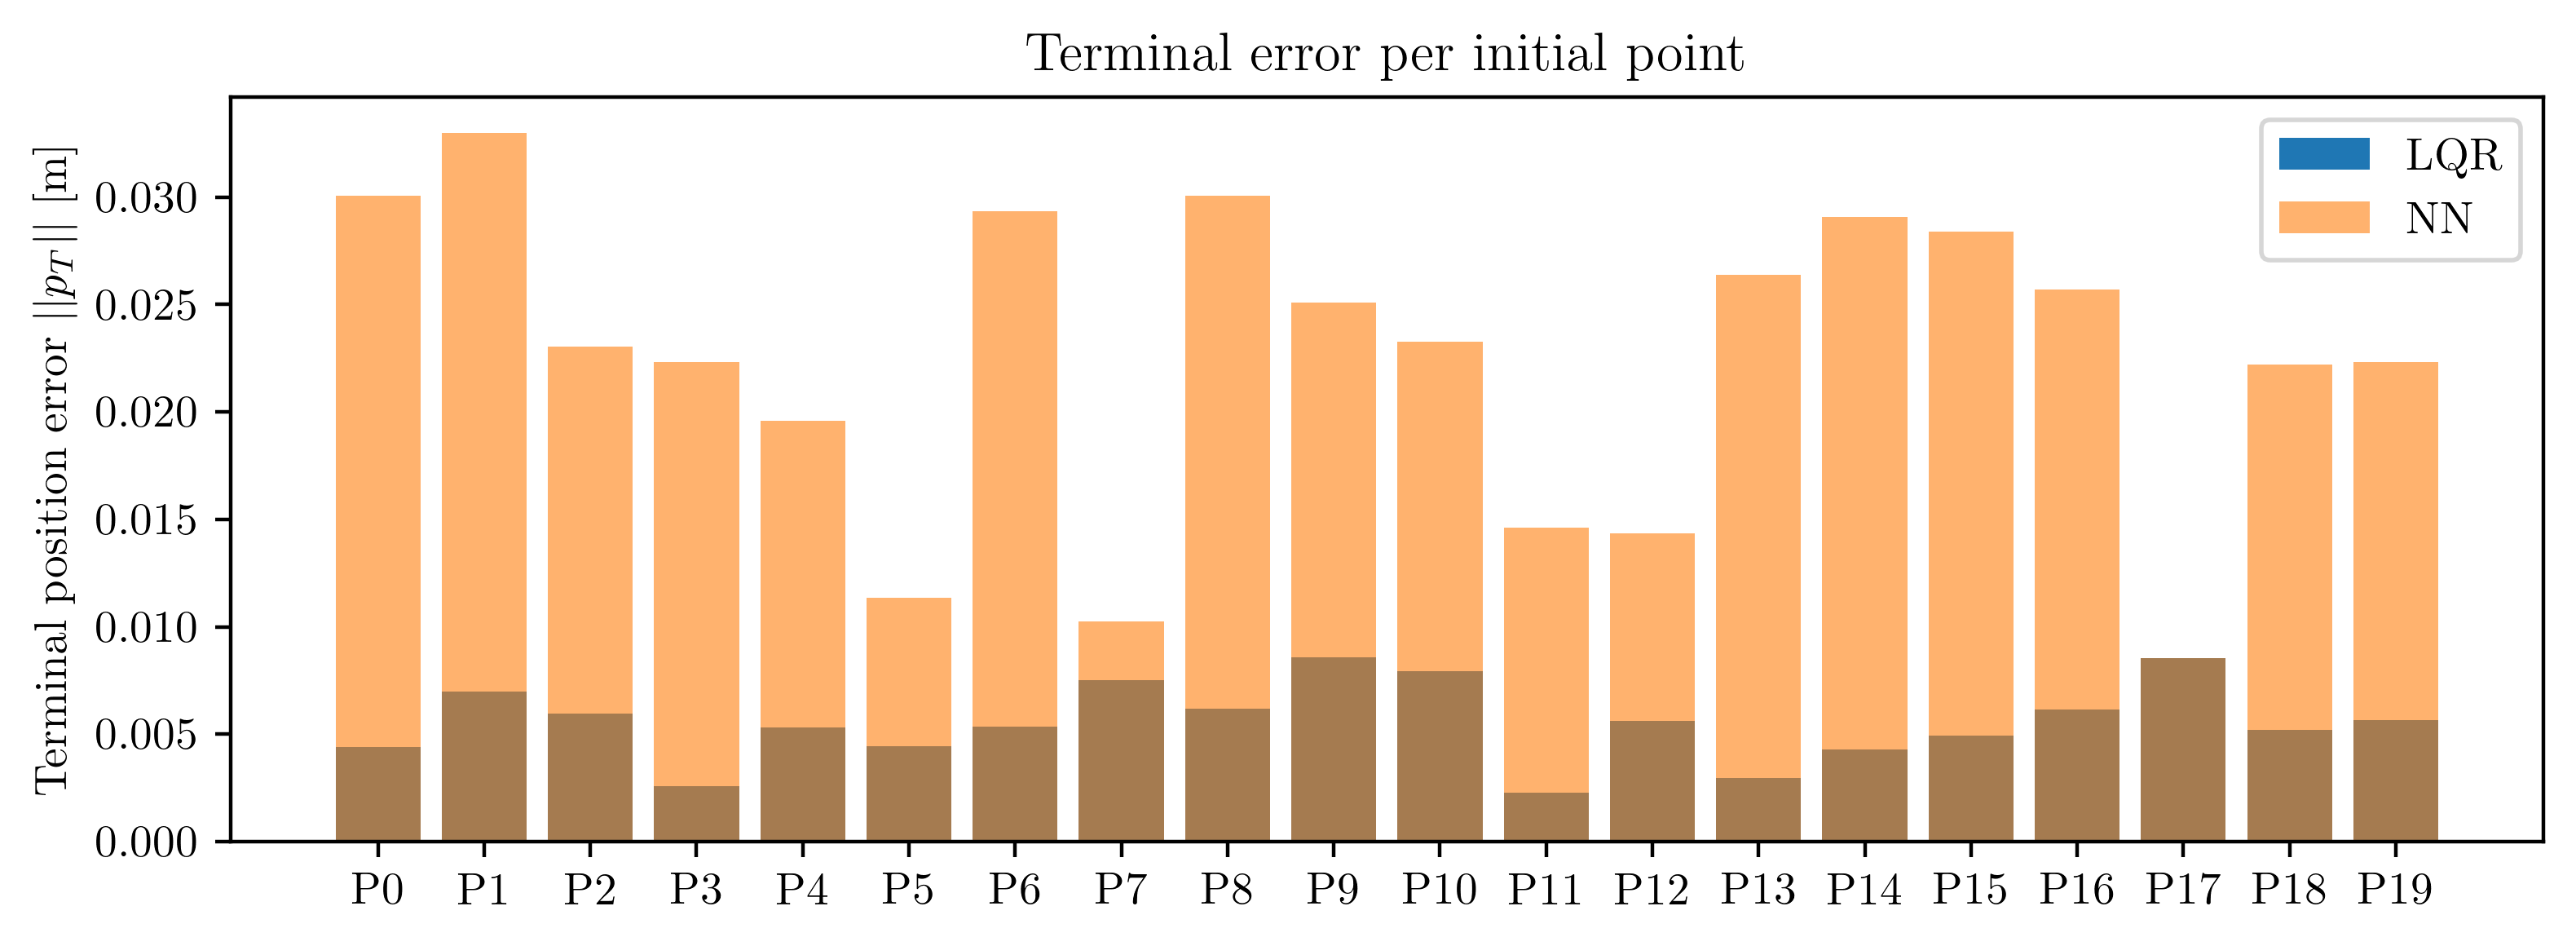

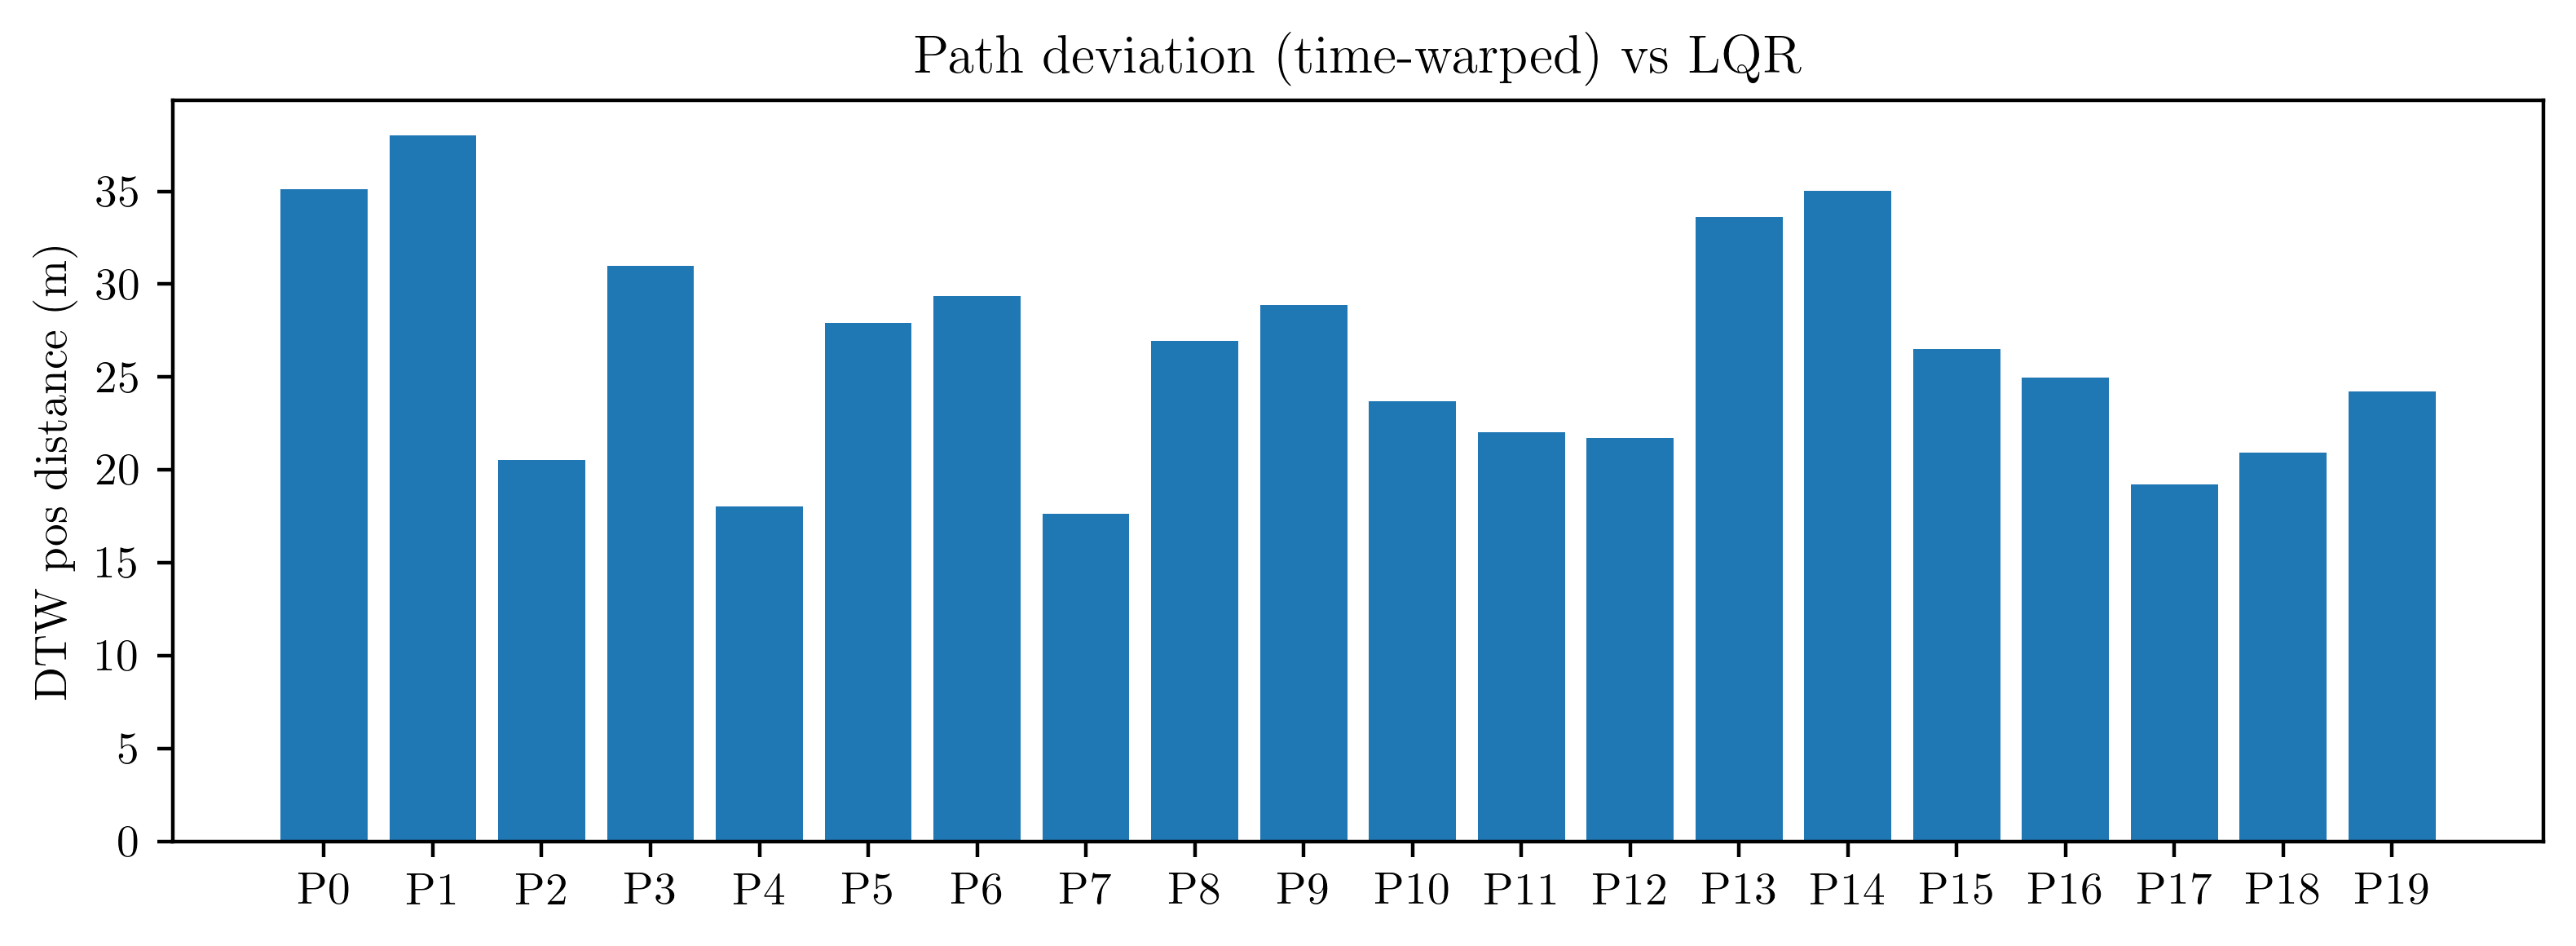

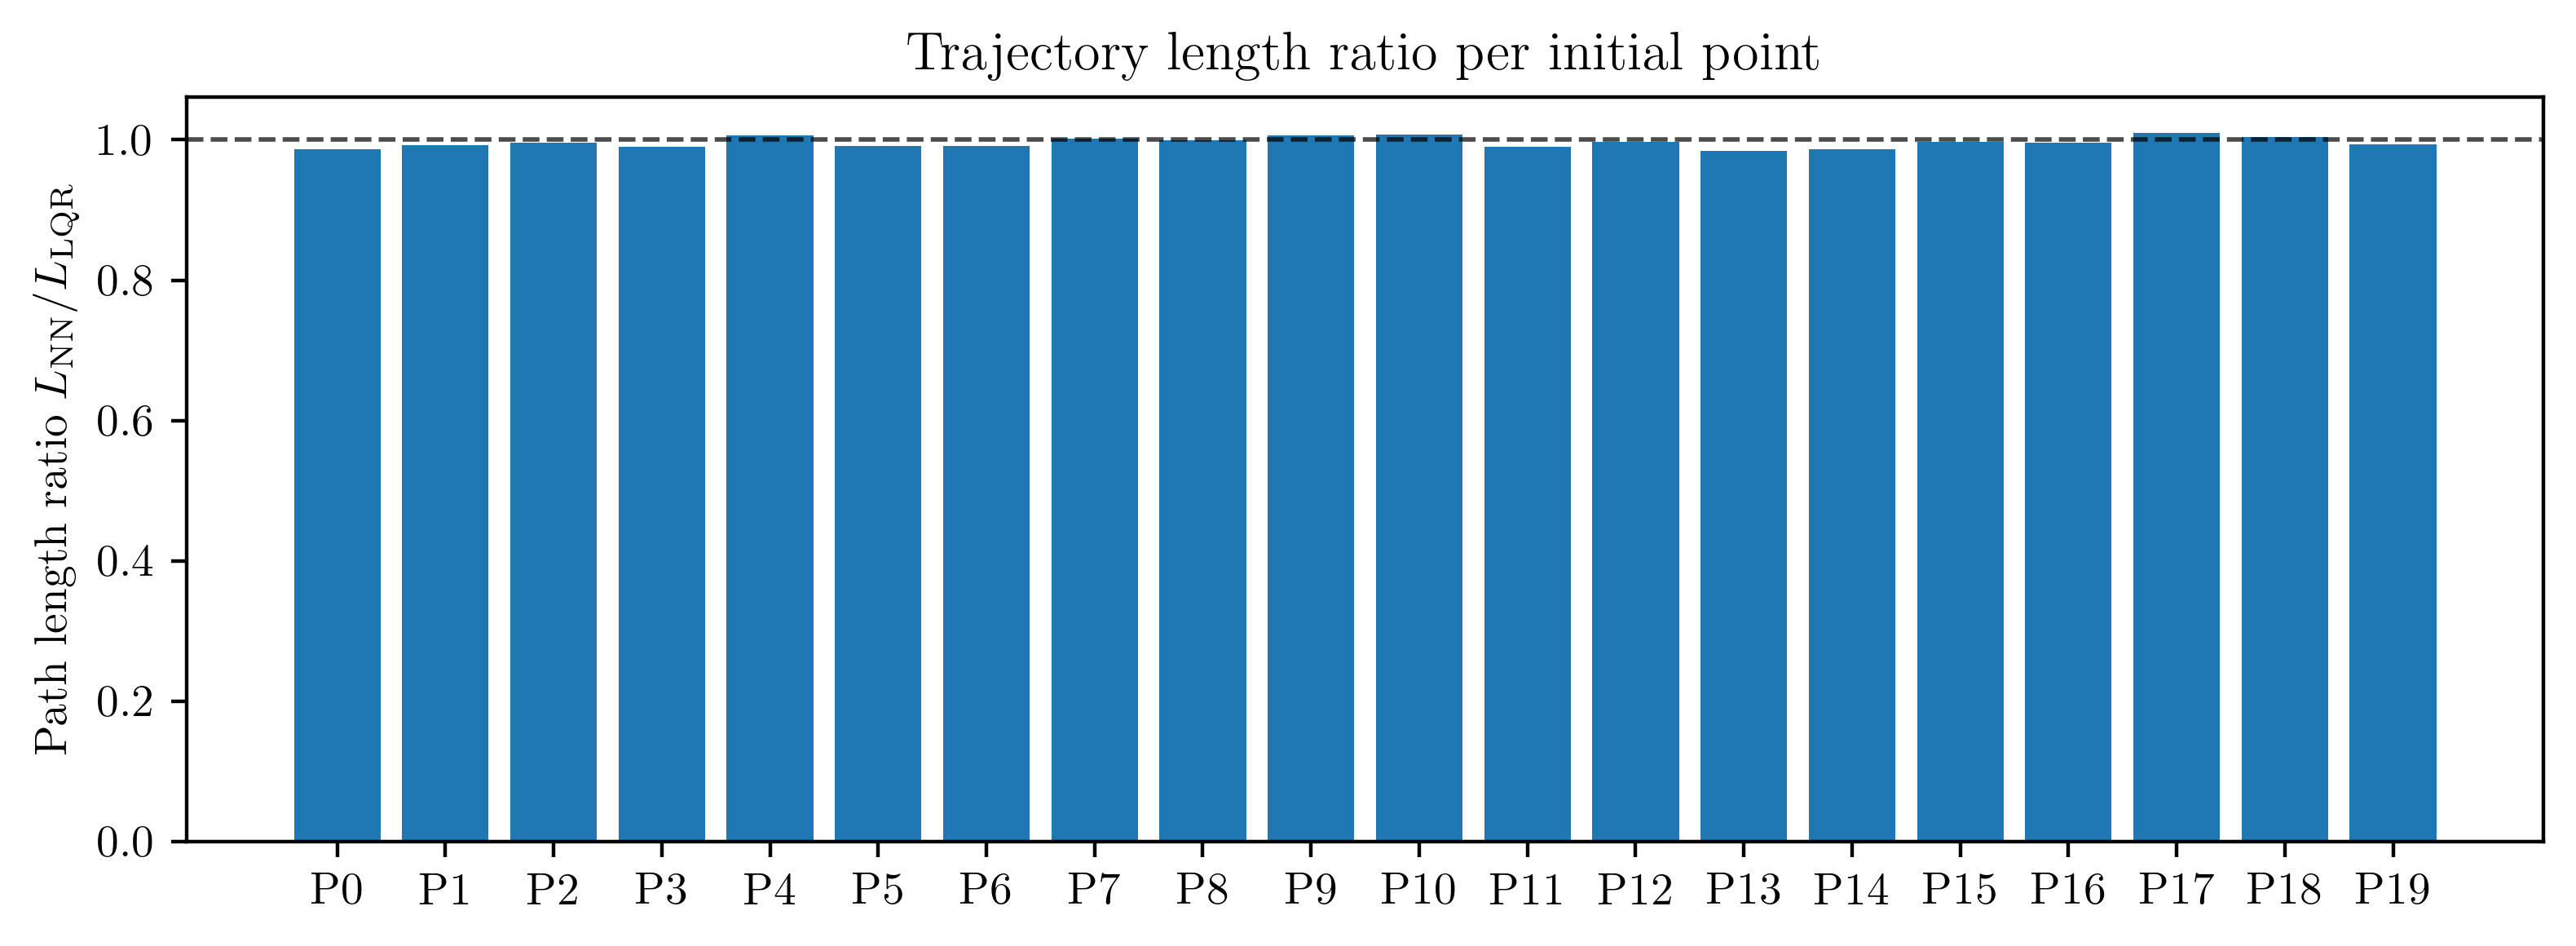

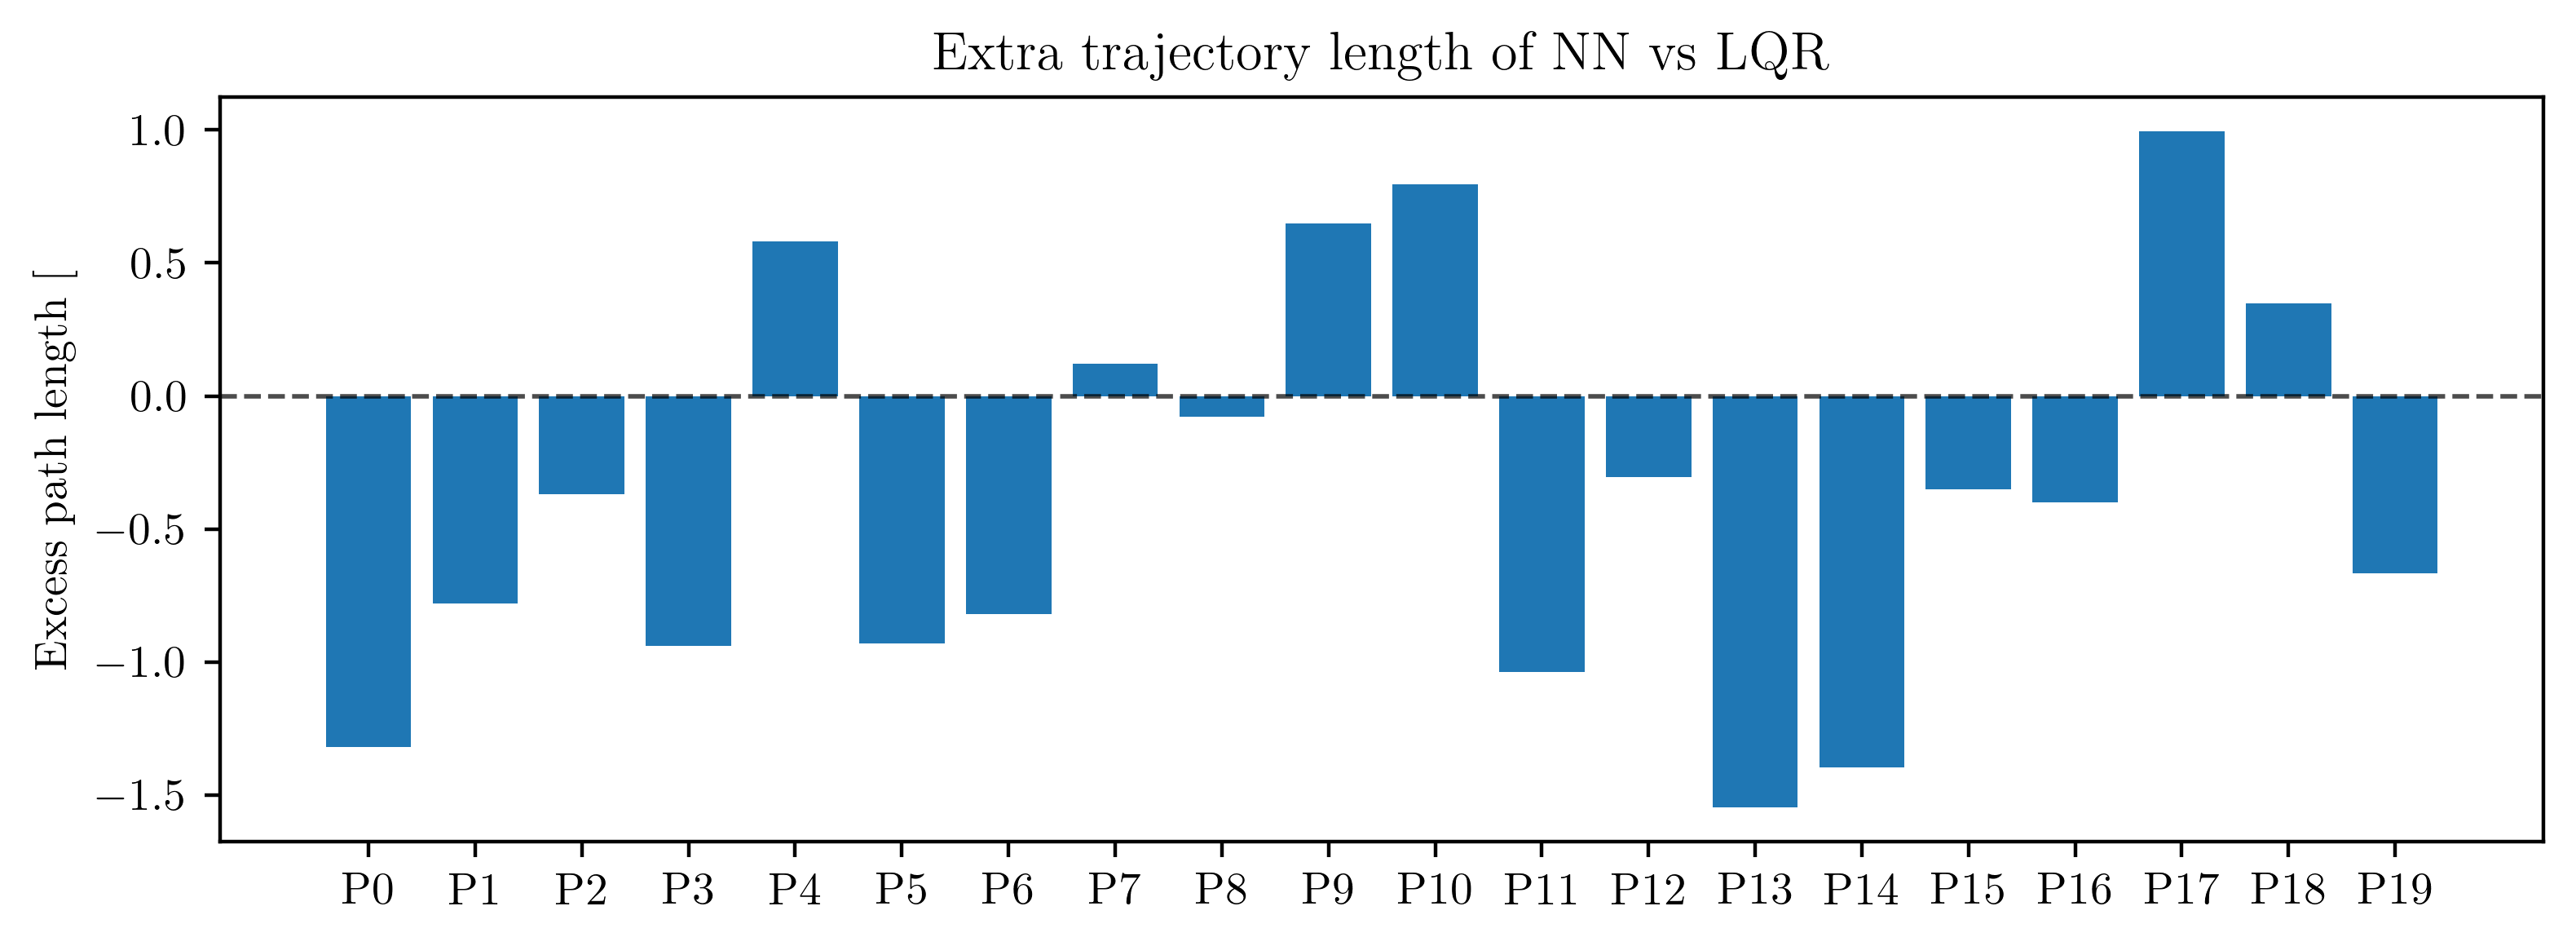

In [ ]:
# Metrics
eT_LQR = terminal_pos_error(X_LQR_TESTING)
eT_NN  = terminal_pos_error(X_NN)

J_LQR = cum_cost(X_LQR_TESTING, U_LQR_TESTING, Q_diag, R_diag, terminal_pos_weight=0.0)
J_NN  = cum_cost(X_NN,  U_NN,  Q_diag, R_diag, terminal_pos_weight=0.0)
J_ratio = (J_NN / (J_LQR + 1e-9)).cpu().numpy()
print(J_ratio)

DTW = batch_dtw_distance(X_LQR_TESTING, X_NN).cpu().numpy()

L_LQR  = path_length(X_LQR_TESTING)
L_NN   = path_length(X_NN)
ratio, excess_pct = path_length_ratio(X_LQR_TESTING, X_NN)

labels = [f"P{b}" for b in range(X_LQR_TESTING.shape[0])]

plt.figure(figsize=(8,3))
plt.bar(labels, J_ratio)
plt.ylabel(r"$J_{\mathrm{NN}}/J_{\mathrm{LQR}}$")
plt.title("Cost ratio per initial point")
plt.tight_layout(); plt.savefig("cmp_cost_ratio.png")

plt.figure(figsize=(8,3))
plt.bar(labels, eT_LQR.cpu().numpy(), label="LQR")
plt.bar(labels, eT_NN.cpu().numpy(),  alpha=0.6, label="NN")
plt.ylabel(r"Terminal position error $||p_T||$ [m]")
plt.title("Terminal error per initial point")
plt.legend(); plt.tight_layout(); plt.savefig("cmp_terminal_error.png")

plt.figure(figsize=(8,3))
plt.bar(labels, DTW)
plt.ylabel("DTW pos distance (m)")
plt.title("Path deviation (time-warped) vs LQR")
plt.tight_layout(); plt.savefig("cmp_dtw.png")

plt.figure(figsize=(8,3))
plt.bar(labels, ratio.cpu().numpy())
plt.axhline(1.0, color="k", ls="--", lw=1, alpha=0.7)
plt.ylabel(r"Path length ratio $L_{\mathrm{NN}}/L_{\mathrm{LQR}}$")
plt.title("Trajectory length ratio per initial point")
plt.tight_layout(); plt.savefig("cmp_path_length_ratio.png")

plt.figure(figsize=(8,3))
plt.bar(labels, excess_pct.cpu().numpy())
plt.axhline(0.0, color="k", ls="--", lw=1, alpha=0.7)
plt.ylabel("Excess path length [%]")
plt.title("Extra trajectory length of NN vs LQR")
plt.tight_layout(); plt.savefig("cmp_path_length_excess.png")
